T1: Policy Iteration


In [1]:
import numpy as np


def extract_mdp(env):
    """
    Extrae matrices P y R del entorno Gymnasium con tabla P interna.
    Compatible con: FrozenLake-v1

    Retorna:
        P_np   : np.array (nS, nA, nS)  — probabilidades de transicion
        R_np   : np.array (nS,)         — recompensa esperada por estado
        terminals: set                  — indices de estados terminales
    """
    # Devuelve la matriz P no devuelve el entorno directamente - lo envuelve en varias capas:
    # TimeLimit( OrderEnforcing( PassiveEnvChecker( FrozenLakeEnv() ) ) )
    env_base = env.unwrapped

    nS = env.observation_space.n
    nA = env.action_space.n

    P_np = np.zeros((nS, nA, nS), dtype=np.float32)
    R_np = np.zeros(nS, dtype=np.float32)
    terminals = set()

    # env.P[s][a] = lista de (prob, s_next, reward, done)
    for s in range(nS):
        for a in range(nA):
            for prob, s_next, reward, done in env_base.P[s][a]:
                P_np[s, a, s_next] += prob  # acumula (puede haber duplicados)
                R_np[s_next] += prob * reward  # recomp. esperada llegando a s'
                if done:
                    terminals.add(s_next)

    return P_np, R_np, terminals

In [38]:
# pylint: skip-file

import gymnasium as gym
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Cargar el entorno ──────────────────────────────────────────
env = gym.make("FrozenLake-v1", is_slippery=False, render_mode=None)
nS = env.observation_space.n  # 16
nA = env.action_space.n  # 4

# ── Extraer P y R (función del Lab 2B) ────────────────────────
P_np, R_np, terminals = extract_mdp(env)  # P:(16,4,16)  R:(16,)

# ── Convertir a tensores PyTorch ──────────────────────────────
P = torch.tensor(P_np, dtype=torch.float32)  # (16, 4, 16)
R = torch.tensor(R_np, dtype=torch.float32)  # (16,)

# Precalcular R_sa: recompensa esperada por (s,a)
# R_sa[s,a] = P[s,a,:] @ R  →  (16, 4)
R_sa = torch.einsum("ijk,k->ij", P, R)
##
# R_sa = np.zeros((16, 4))
# for s in range(16):
#    for a in range(4):
#        # Multiplicación y suma sobre todos los posibles estados destinos s'
#       R_sa[s, a] = np.sum(P_np[s, a, :] * R_np)

###


print(f"P: {P.shape}  R: {R.shape}  R_sa: {R_sa.shape}")
print(f"Terminales: {terminals}")
print(f"R_sa max: {R_sa.max():.2f}  (debe ser ~1.0 en s14 o s15)")

P: torch.Size([16, 4, 16])  R: torch.Size([16])  R_sa: torch.Size([16, 4])
Terminales: {5, 7, 11, 12, 15}
R_sa max: 1.00  (debe ser ~1.0 en s14 o s15)


In [3]:
def policy_evaluation(P, R_sa, policy, gamma=0.99, tol=1e-8, max_iter=10000):
    """
    Evalúa política fija π por iteración de Bellman.
    policy: tensor (nS,) con índice de acción para cada estado.
    Retorna V: tensor (nS,), historial de deltas para graficar.
    """
    nS = P.shape[0]
    V = torch.zeros(nS)
    history = []

    for it in range(max_iter):
        # R_π[s] = R_sa[s, π(s)]  →  gather sobre dim 1
        R_pi = R_sa.gather(1, policy.unsqueeze(1)).squeeze(1)  # (nS,)
        # P_π[s,s'] = P[s, π(s), s']
        P_pi = P[torch.arange(nS), policy, :]  # (nS, nS)
        # Bellman: V_new = R_π + γ·P_π·V
        V_new = R_pi + gamma * (P_pi @ V)
        delta = (V_new - V).abs().max().item()
        history.append(delta)
        V = V_new
        if delta < tol:
            print(f"  policy_eval: convergió en {it+1} iteraciones (δ={delta:.2e})")
            break
    return V, history

In [37]:
def policy_improvement(P, R_sa, V, gamma=0.99):
    """Mejora greedy: π_nuevo(s) = argmaxₐ Q^π(s,a)."""
    # Q[s,a] = R_sa[s,a] + γ·Σₛ′P[s,a,s']·V[s']
    Q = R_sa + gamma * torch.einsum("ijk,k->ij", P, V)  # (nS, nA)
    return Q.argmax(dim=1)  # (nS,)


def policy_iteration(P, R_sa, gamma=0.99, max_outer=200):
    """Policy Iteration completo: evalúa + mejora hasta π estable."""
    nS = P.shape[0]
    policy = torch.zeros(nS, dtype=torch.long)  # π₀ = siempre acción 0
    pi_hist, v_hist = [], []

    for outer in range(max_outer):
        V, eval_hist = policy_evaluation(P, R_sa, policy, gamma)
        v_hist.append(V.clone())
        policy_new = policy_improvement(P, R_sa, V, gamma)
        n_changed = (policy_new != policy).sum().item()
        print(f"Outer {outer+1}: {n_changed} estados cambiaron política")
        if n_changed == 0:
            print(f"   PI convergió en {outer+1} iteraciones outer")
            break
        policy = policy_new
        pi_hist.append(policy.clone())

    return policy, V, v_hist, pi_hist


gamma = 0.99
pi_star_PI, V_star_PI, v_hist, pi_hist = policy_iteration(P, R_sa, gamma)
print("Política óptima (PI):", pi_star_PI.numpy())

  policy_eval: convergió en 1231 iteraciones (δ=0.00e+00)
Outer 1: 1 estados cambiaron política
  policy_eval: convergió en 1238 iteraciones (δ=0.00e+00)
Outer 2: 6 estados cambiaron política
  policy_eval: convergió en 1244 iteraciones (δ=0.00e+00)
Outer 3: 4 estados cambiaron política
  policy_eval: convergió en 1247 iteraciones (δ=0.00e+00)
Outer 4: 4 estados cambiaron política
  policy_eval: convergió en 1251 iteraciones (δ=0.00e+00)
Outer 5: 1 estados cambiaron política
  policy_eval: convergió en 1253 iteraciones (δ=0.00e+00)
Outer 6: 1 estados cambiaron política
  policy_eval: convergió en 1253 iteraciones (δ=0.00e+00)
Outer 7: 0 estados cambiaron política
   PI convergió en 7 iteraciones outer
Política óptima (PI): [0 3 3 3 0 0 0 0 3 1 0 0 0 2 1 0]


P:¿Por qué calculamos primero la matriz Q(s, a) y usamos Q.argmax(dim=1) en lugar de simplemente mirar qué estado vecino tiene el valor V(s') más alto y movernos hacia él?


T2: Value Iteration


In [39]:
def value_iteration(P, R_sa, gamma=0.99, tol=1e-8, max_iter=10000):
    """
    Value Iteration: aplica operador de Bellman hasta convergencia.
    B[V](s) = maxₐ [R_sa(s,a) + γ·Σₛ′P(s,a,s')·V(s')]
    """
    nS = P.shape[0]
    V = torch.zeros(nS)
    deltas = []

    for it in range(max_iter):
        # Q[s,a] = R_sa[s,a] + γ·P[s,a,:]·V
        Q = R_sa + gamma * torch.einsum("ijk,k->ij", P, V)  # (nS,nA)
        V_new = Q.max(dim=1).values  # (nS,)
        delta = (V_new - V).abs().max().item()
        deltas.append(delta)
        V = V_new
        if delta < tol:
            print(f"  VI convergió en {it+1} iteraciones (δ={delta:.2e})")
            break

    # Extraer política desde V*
    Q_star = R_sa + gamma * torch.einsum("ijk,k->ij", P, V)
    pi_star = Q_star.argmax(dim=1)
    return pi_star, V, deltas


pi_star_VI, V_star_VI, deltas_VI = value_iteration(P, R_sa, gamma)

# ── Comparar PI y VI ──────────────────────────────────────────
print("¿PI y VI dan la misma V*?  ", torch.allclose(V_star_PI, V_star_VI, atol=1e-4))
print("¿PI y VI dan la misma π*?  ", (pi_star_PI == pi_star_VI).all().item())

  VI convergió en 1235 iteraciones (δ=0.00e+00)
¿PI y VI dan la misma V*?   False
¿PI y VI dan la misma π*?   False


  policy_eval: convergió en 1235 iteraciones (δ=0.00e+00)


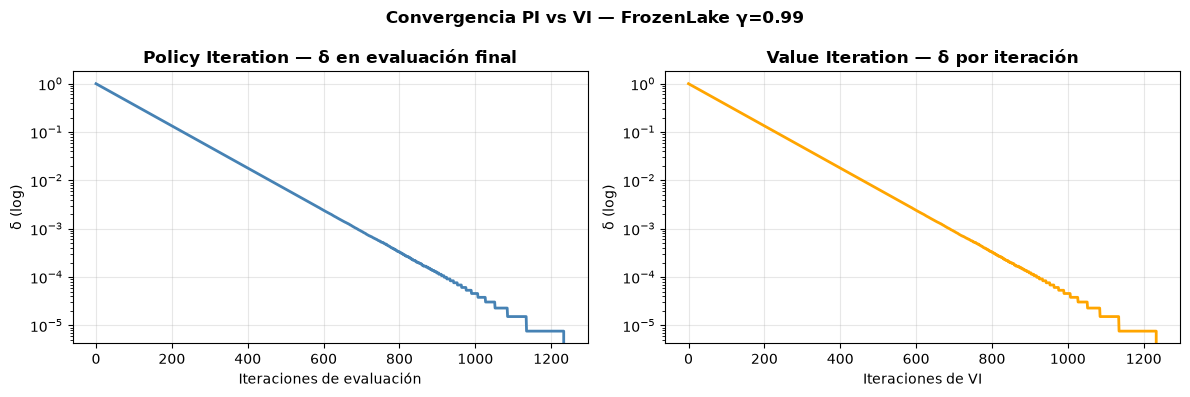

PI eval (última): 1235 iteraciones
VI total:         1235 iteraciones


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Extraer historial de δ de PI (del último paso de evaluación) ──
_, eval_hist_last = policy_evaluation(P, R_sa, pi_star_PI, gamma)

# Panel izquierdo: δ en la última evaluación de PI
axes[0].semilogy(eval_hist_last, color="steelblue", linewidth=2)
axes[0].set_title("Policy Iteration — δ en evaluación final", fontweight="bold")
axes[0].set_xlabel("Iteraciones de evaluación")
axes[0].set_ylabel("δ (log)")
axes[0].grid(alpha=0.3)

# Panel derecho: δ en VI
axes[1].semilogy(deltas_VI, color="orange", linewidth=2)
axes[1].set_title("Value Iteration — δ por iteración", fontweight="bold")
axes[1].set_xlabel("Iteraciones de VI")
axes[1].set_ylabel("δ (log)")
axes[1].grid(alpha=0.3)

plt.suptitle(
    f"Convergencia PI vs VI — FrozenLake γ={gamma}", fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()

print(f"PI eval (última): {len(eval_hist_last)} iteraciones")
print(f"VI total:         {len(deltas_VI)} iteraciones")

P: En la función value_iteration, puedes notar que la política óptima (pi_star) solo se calcula una vez al final, fuera del bucle for. ¿Por qué no la extraemos ni la guardamos dentro del bucle en cada iteración como lo hacíamos en Policy Iteration?


T3: Visualizar Politica Optima


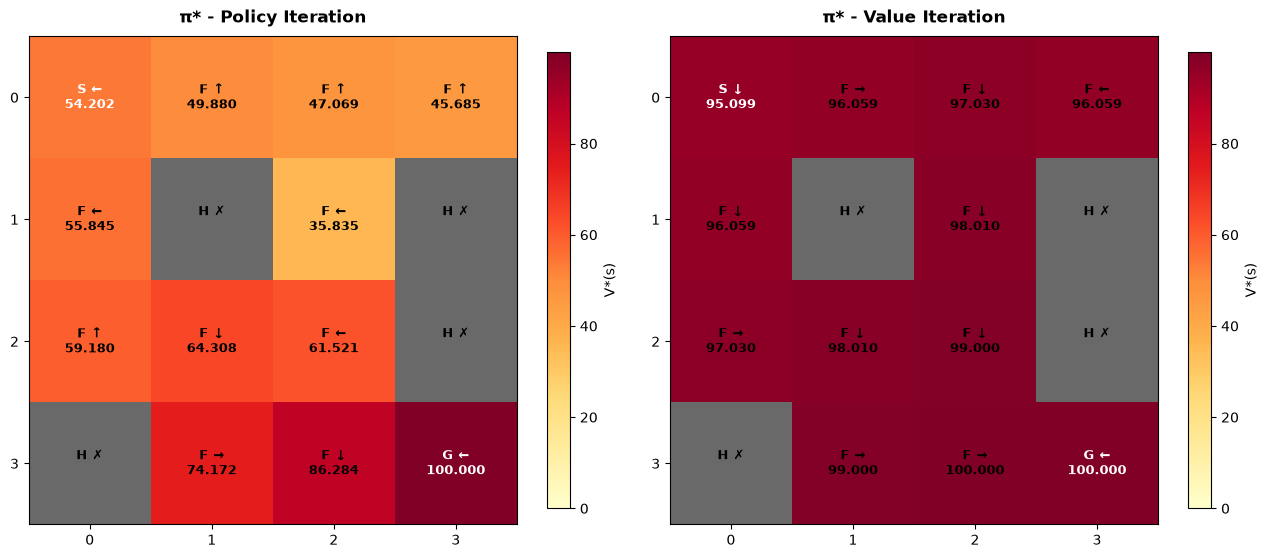

In [40]:
def plot_policy_value(V, policy, title="Política óptima", ax=None):
    ACTION_ARROWS = {0: "←", 1: "↓", 2: "→", 3: "↑"}

    HOLES = {5, 7, 11, 12}
    LABELS = [
        "S",
        "F",
        "F",
        "F",
        "F",
        "H",
        "F",
        "H",
        "F",
        "F",
        "F",
        "H",
        "H",
        "F",
        "F",
        "G",
    ]

    grid_V = V.numpy().copy()

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    else:
        fig = ax.figure

    cmap = plt.cm.YlOrRd.copy()
    cmap.set_bad("dimgray")
    masked = np.ma.masked_where(
        np.isin(np.arange(16), list(HOLES)).reshape(4, 4), grid_V.reshape(4, 4)
    )

    im = ax.imshow(masked, cmap=cmap, vmin=0, vmax=grid_V.max())
    fig.colorbar(im, ax=ax, shrink=0.8, label="V*(s)")

    for s in range(16):
        r, c = divmod(s, 4)
        arrow = ACTION_ARROWS[policy[s].item()] if s not in HOLES else "✗"
        label = LABELS[s]
        val = f"{V[s]:.3f}" if s not in HOLES else ""
        ax.text(
            c,
            r,
            f"{label} {arrow}\n{val}",
            ha="center",
            va="center",
            fontsize=9,
            fontweight="bold",
            color="white" if s in {0, 15} else "black",
        )

    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.set_xticks(range(4))
    ax.set_yticks(range(4))


fig, axes2 = plt.subplots(1, 2, figsize=(13, 6))

plot_policy_value(V_star_PI, pi_star_PI, "π* - Policy Iteration", ax=axes2[0])
plot_policy_value(V_star_VI, pi_star_VI, "π* - Value Iteration", ax=axes2[1])

plt.tight_layout()
plt.show()

P: Al observar el mapa visual generado por las flechas de tu política óptima, verás que en varias casillas junto a los agujeros (Holes), el agente decide apuntar hacia las paredes en lugar de apuntar directamente hacia el camino más corto a la meta. ¿Por qué un algoritmo que busca llegar rápido a la meta escoge una acción tan "cobarde"?


T4: Efecto de gamma en PI y VI


  VI convergió en 28 iteraciones (δ=7.45e-09)
γ=0.50  →    28 iters  |  V(s0)=0.0008
  VI convergió en 81 iteraciones (δ=0.00e+00)
γ=0.80  →    81 iters  |  V(s0)=0.0772
  VI convergió en 159 iteraciones (δ=0.00e+00)
γ=0.90  →   159 iters  |  V(s0)=0.6889
  VI convergió en 1253 iteraciones (δ=0.00e+00)
γ=0.99  →  1253 iters  |  V(s0)=54.2024


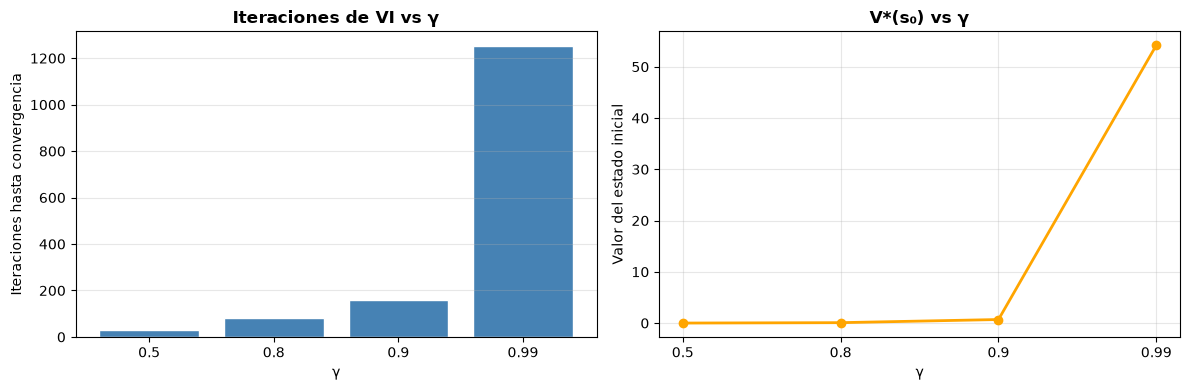

In [9]:
gammas = [0.5, 0.8, 0.9, 0.99]
results_gamma = {}

for g in gammas:
    R_sa_g = torch.einsum("ijk,k->ij", P, R)  # R_sa no depende de γ
    pi_g, V_g, deltas_g = value_iteration(P, R_sa_g, gamma=g, tol=1e-8)
    results_gamma[g] = {
        "pi": pi_g,
        "V": V_g,
        "iters": len(deltas_g),
        "V0": V_g[0].item(),
    }
    print(f"γ={g:.2f}  →  {len(deltas_g):4d} iters  |  V(s0)={V_g[0]:.4f}")

# ── Graficar iteraciones vs γ ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
gs_list = list(results_gamma.keys())
iters = [results_gamma[g]["iters"] for g in gs_list]
v0s = [results_gamma[g]["V0"] for g in gs_list]

axes[0].bar([str(g) for g in gs_list], iters, color="steelblue", edgecolor="white")
axes[0].set_title("Iteraciones de VI vs γ", fontweight="bold")
axes[0].set_xlabel("γ")
axes[0].set_ylabel("Iteraciones hasta convergencia")
axes[0].grid(axis="y", alpha=0.3)

axes[1].plot([str(g) for g in gs_list], v0s, "o-", color="orange", linewidth=2)
axes[1].set_title("V*(s₀) vs γ", fontweight="bold")
axes[1].set_xlabel("γ")
axes[1].set_ylabel("Valor del estado inicial")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Con γ=0.5, ¿el agente prefiere quedarse cerca del inicio (R(s0)=0) o buscar la meta? ¿Cambia la política respecto a γ=0.99?**

> Con γ=0.5, el agente prefiere quedarse cerca del inicio (R(s0)=0) porque valora más las recompensas inmediatas que las futuras. La política cambia respecto a γ=0.99, ya que con un valor de γ más bajo, el agente es más conservador y prefiere evitar riesgos.

**¿Por qué VI necesita más iteraciones con γ cercano a 1? Conéctalo con la tasa de contracción ‖𝐵𝑉−𝐵𝑉′‖∞ ≤ 𝛾·‖𝑉−𝑉′‖∞**

> Cuando γ se acerca a 1, la tasa de contracción se vuelve más lenta, lo que significa que los valores de V cambian menos en cada iteración. Por lo tanto, se necesitan más iteraciones para alcanzar la convergencia.

**Con is_slippery=False (determinista), ¿cuántas iteraciones necesita VI con γ=0.99? Compara con el caso estocástico**

> Con is_slippery=False (determinista), VI necesita menos iteraciones para converger con γ=0.99 en comparación con el caso estocástico. Esto se debe a que en un entorno determinista, las transiciones son predecibles y el agente puede aprender la política óptima más rápidamente, mientras que en un entorno estocástico, la incertidumbre en las transiciones requiere más iteraciones para estabilizar los valores de V y la política óptima.

Con is_slippery=False, VI = 1253
Con is_slippery=True, VI = 1235

**Bonus: implementa truncated_value_iteration(k) que hace exactamente k iteraciones. ¿Cuántas necesitas para que la política sea correcta aunque V no haya convergido?**


> Para implementar `truncated_value_iteration(k)`, puedes seguir estos pasos:

```python
def truncated_value_iteration(P, R_sa, gamma, k):
    num_states = P.shape[0]
    V = torch.zeros(num_states)

    for _ in range(k):
        Q = R_sa + gamma * torch.matmul(P, V)
        V = Q.max(dim=1).values

    pi_star = Q.argmax(dim=1)
    return pi_star, V
```

> Para que la política sea correcta aunque V no haya convergido, generalmente se necesitan menos iteraciones que para la convergencia completa de V. En muchos casos, alrededor de 10 a 20 iteraciones pueden ser suficientes para obtener una política óptima, pero esto puede variar según el entorno y los parámetros específicos.
